<a href="https://colab.research.google.com/github/Konstantinospapako/Konstantinospapako/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

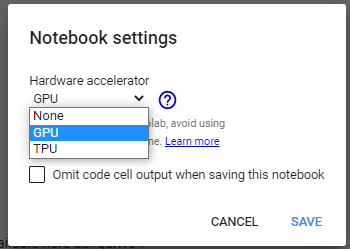

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


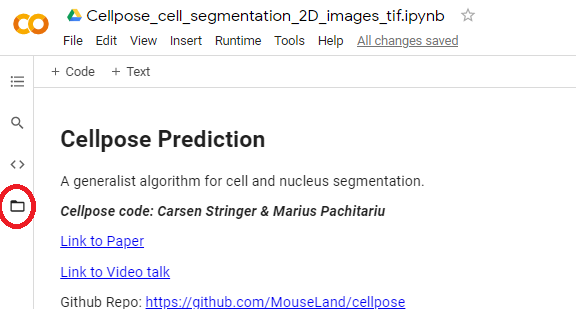

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

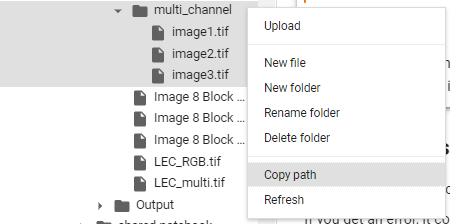

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [2]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-ooqh1zgf
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-ooqh1zgf
  Resolved https://www.github.com/mouseland/cellpose.git to commit 9604421222c51d96636c2547e33fbd7d4f766c2a
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 84.1 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.8.dev24+g960442122-py3-none-any.whl size=212893 sha256=72cdd48351d08c7ea79dd270b635a056ba6bd22655ae18251258a39b42a206ea
  Stored in directory: /tmp/pip-ephem-wheel-cache-th_nh49j/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


Check GPU and instantiate model - will download weights.

In [3]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2025-11-27 18:38:36,068 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2025-11-27 18:38:36,069 [INFO] 
cellpose version: 	4.0.8.dev24+g960442122 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.9.0+cu126
2025-11-27 18:38:36,295 [INFO] ** TORCH CUDA version installed and working. **
2025-11-27 18:38:36,297 [INFO] ** TORCH CUDA version installed and working. **
2025-11-27 18:38:36,298 [INFO] >>>> using GPU (CUDA)
2025-11-27 18:38:39,012 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:05<00:00, 208MB/s]


Input directory with your images:

In [5]:
# *** change to your google drive folder path ***
dir = "/content/drive/MyDrive/DIC-C2DH-HeLa/01"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

84 images in folder:
t000.tif
t001.tif
t002.tif
t003.tif
t004.tif
t005.tif
t006.tif
t007.tif
t008.tif
t009.tif
t010.tif
t011.tif
t012.tif
t013.tif
t014.tif
t015.tif
t016.tif
t017.tif
t018.tif
t019.tif
t020.tif
t021.tif
t022.tif
t023.tif
t024.tif
t025.tif
t026.tif
t027.tif
t028.tif
t029.tif
t030.tif
t031.tif
t032.tif
t033.tif
t034.tif
t035.tif
t036.tif
t037.tif
t038.tif
t039.tif
t040.tif
t041.tif
t042.tif
t043.tif
t044.tif
t045.tif
t046.tif
t047.tif
t048.tif
t049.tif
t050.tif
t051.tif
t052.tif
t053.tif
t054.tif
t055.tif
t056.tif
t057.tif
t058.tif
t059.tif
t060.tif
t061.tif
t062.tif
t063.tif
t064.tif
t065.tif
t066.tif
t067.tif
t068.tif
t069.tif
t070.tif
t071.tif
t072.tif
t073.tif
t074.tif
t075.tif
t076.tif
t077.tif
t078.tif
t079.tif
t080.tif
t081.tif
t082.tif
t083.tif


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [7]:
img = io.imread(files[2])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (512, 512). Assuming channel dimension is last with 512 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [10]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]

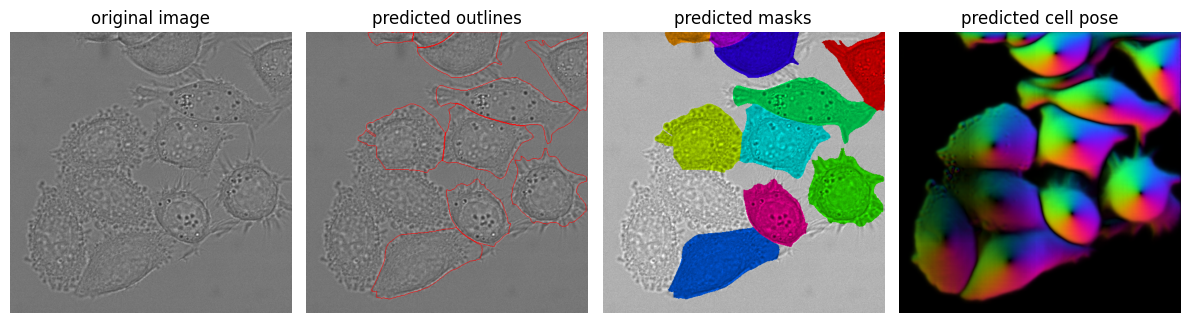

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1. Ensure img is 3D (H, W, C)
# ------------------------------
if img.ndim == 2:
    # grayscale → convert to 3D with 1 channel
    img = img[:, :, None]

# ------------------------------
# 2. Collect selected channels
# ------------------------------
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
    if c == 'None':
        continue
    if int(c) >= img.shape[-1]:
        raise ValueError("Invalid channel index — must be less than the number of channels")
    selected_channels.append(int(c))

# If no channels selected → use all
if len(selected_channels) == 0:
    selected_channels = list(range(img.shape[-1]))

# ------------------------------
# 3. Create img_selected_channels
# ------------------------------
img_selected_channels = img[:, :, selected_channels]

# ------------------------------
# 4. Cellpose evaluation
# ------------------------------
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(
    img_selected_channels,
    batch_size=32,
    flow_threshold=flow_threshold,
    cellprob_threshold=cellprob_threshold,
    normalize={"tile_norm_blocksize": tile_norm_blocksize}
)

# ------------------------------
# 5. Plot segmentation
# ------------------------------
fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [14]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

  1%|          | 1/84 [00:04<06:16,  4.53s/it]


KeyboardInterrupt: 

if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
    io.save_rois(masks0, f)

In [16]:
import numpy as np
from tifffile import imread

gt = imread("/content/drive/MyDrive/DIC-C2DH-HeLa/01_GT/SEG/man_seg002.tif")
#pred = imread("prediction.tif")

print("GT unique values:", np.unique(gt)[:10])
#print("Pred unique values:", np.unique(pred)[:10])


GT unique values: [0 1 2 3 4 5 6 7 8 9]


In [17]:
import numpy as np

def instance_to_binary(mask):
    return (mask > 0).astype(np.uint8)
def prob_to_binary(pred, threshold=0.5):
    return (pred >= threshold).astype(np.uint8)
def iou_score(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    if union == 0:
        return 1.0
    return intersection / union

def dice_score(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    if gt.sum() + pred.sum() == 0:
        return 1.0
    return 2 * intersection / (gt.sum() + pred.sum())
from tifffile import imread
from pathlib import Path

gt_dir = Path("GT_FOLDER")        # βάλε εδώ φάκελο GT
pred_dir = Path("PRED_FOLDER")   # βάλε εδώ φάκελο predictions

gt_files = sorted(gt_dir.glob("*.tif"))

ious = []
dices = []

for gt_path in gt_files:
    pred_path = pred_dir / gt_path.name  # ίδιο όνομα αρχείου

    gt = imread(gt_path)
    pred = imread(pred_path)

    gt_bin = instance_to_binary(gt)

    # αν το pred είναι probability map:
    pred_bin = prob_to_binary(pred, threshold=0.5)

    ious.append(iou_score(gt_bin, pred_bin))
    dices.append(dice_score(gt_bin, pred_bin))

print("Mean IoU:", np.mean(ious))
print("Mean Dice:", np.mean(dices))


Mean IoU: nan
Mean Dice: nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
